Q1.1: Origin fit (σ1 = q σ3)
  q = 3.8573
  φ = 36.03 deg
  μ = tanφ = 0.7274


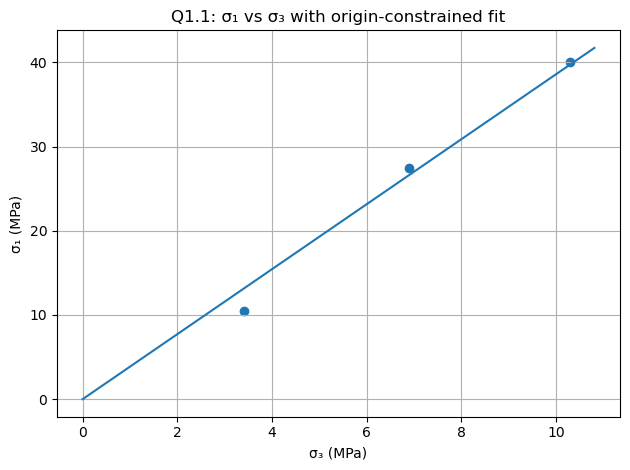


Q1.2: Mohr circles & shear-yield line
  Shear-fracture angle (to σ₁): θ_f = 45° + φ/2 = 63.02°


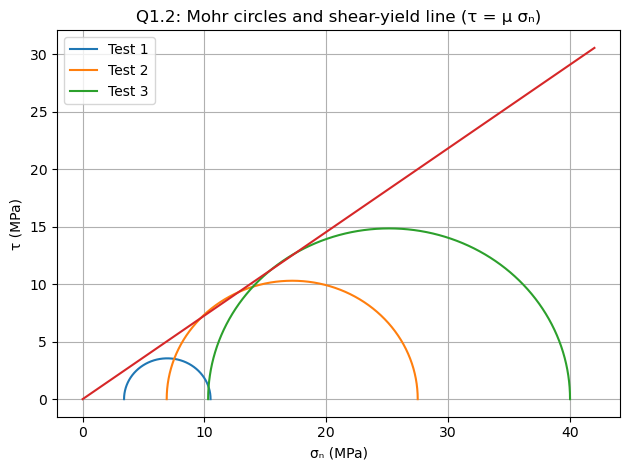


Q2: Auto-detected columns →
  time ← 'Time'
    Pc ← '(s)'
   Dev ← 'Pc'
    Ex ← '(psi)'
    Ey ← 'SigD'


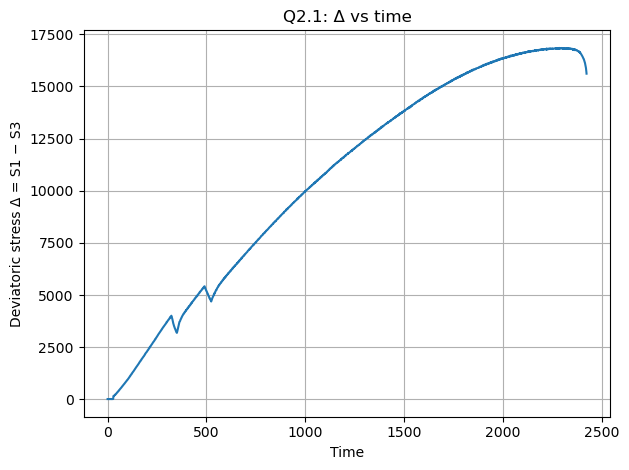

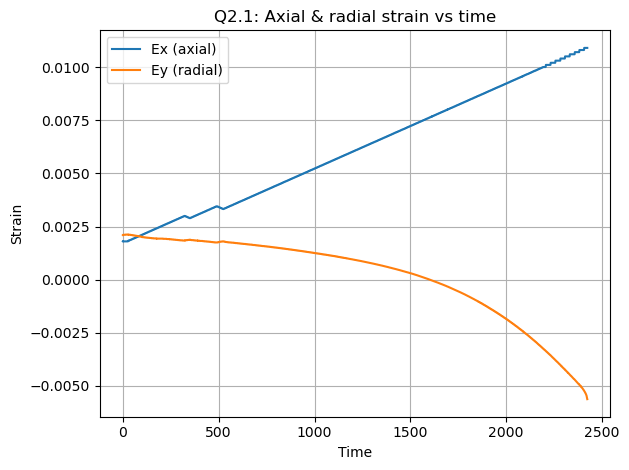

Q2.1: Estimated axial strain rate  dεa/dt ≈ 3.7170e-06 per time unit
Q2.2: Peak Δ = 1.685e+04
      Loading tangent modulus @25% peak: dΔ/dεa ≈ 4.198e+06 (stress units)


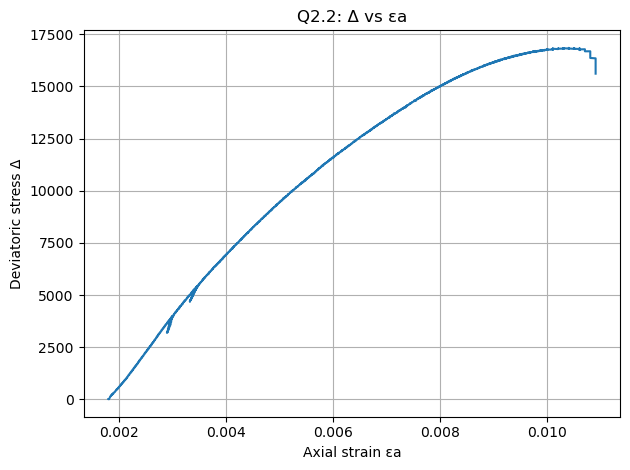

Q2.3: Poisson's ratio (initial window): ν ≈ 0.2211


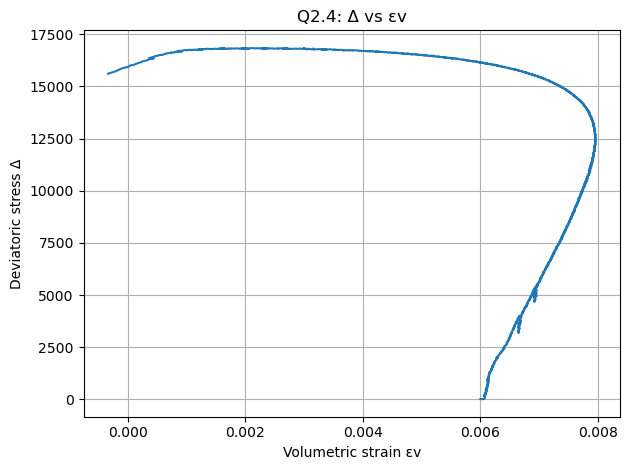

Q2.5: Using q = 5.3, Pc ≈ 1500 → UCS ≈ 1.04e+04 (same stress units as input)

Q3: Fit results (effective stresses)
  q = 3.200
  UCS = 100.08 MPa
  φ = 31.59 deg,  μ = 0.615
  S0 (cohesion parameter) = 27.97 MPa


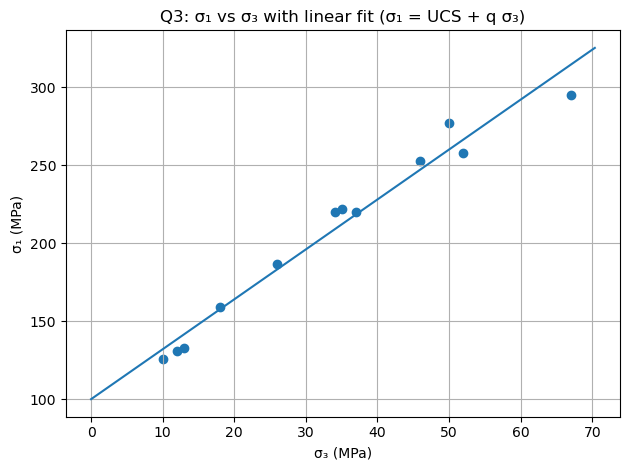

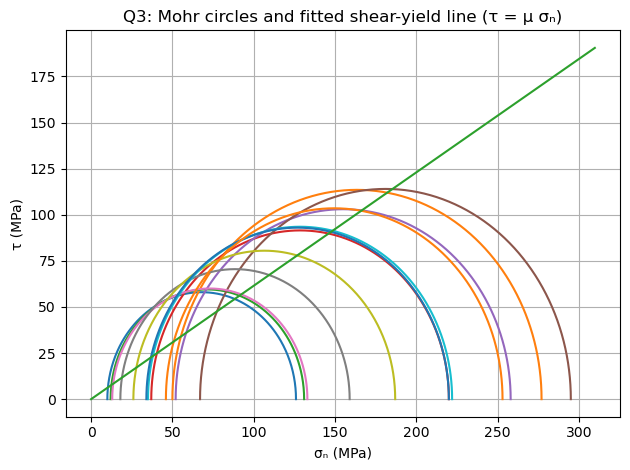

In [11]:
# ============================================================
# Section 4.9 – Problems Q1, Q2, Q3  (Jupyter-ready script)
# - Pure matplotlib (one plot per figure, no custom colors)
# - No seaborn. Works with whitespace- or CSV-like Q2 data.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Utilities shared by Q1 & Q3
# -----------------------------

def q_from_origin_fit(sig3, sig1):
    """Least-squares slope through origin: σ1 = q * σ3."""
    sig3 = np.asarray(sig3, dtype=float)
    sig1 = np.asarray(sig1, dtype=float)
    q = np.sum(sig3 * sig1) / np.sum(sig3**2)
    return q

def phi_from_q(q):
    """Friction angle from q via q=(1+sinφ)/(1−sinφ). Returns (rad, deg)."""
    s = (q - 1.0) / (q + 1.0)
    s = np.clip(s, -1.0, 1.0)
    phi_rad = np.arcsin(s)
    return phi_rad, np.degrees(phi_rad)

def mohr_circle_points(sig1, sig3, n=361):
    """Mohr circle in (σn, τ) for principal stresses (σ1 ≥ σ3)."""
    C = 0.5 * (sig1 + sig3)
    R = 0.5 * (sig1 - sig3)
    th = np.linspace(0, np.pi, n)  # 0..π covers the circle
    sig_n = C + R * np.cos(th)
    tau = R * np.sin(th)
    return sig_n, tau, C, R

def add_mc_series(ax, sig1, sig3, label=None):
    sn, tau, C, R = mohr_circle_points(sig1, sig3)
    ax.plot(sn, tau, label=label)
    return C, R

def shear_line_points(mu, sig_n_max, n=2):
    x = np.linspace(0.0, sig_n_max, n)
    y = mu * x
    return x, y

# ============================================================
# Q1 — Three dry triaxial tests (edit the numbers here if yours differ)
# ============================================================

q1_sig3 = np.array([3.4, 6.9, 10.3])   # MPa
q1_sig1 = np.array([10.5, 27.5, 40.0]) # MPa

# Q1.1 — σ1 vs σ3 with origin-constrained fit
q = q_from_origin_fit(q1_sig3, q1_sig1)
phi_rad, phi_deg = phi_from_q(q)
mu = np.tan(phi_rad)

print("Q1.1: Origin fit (σ1 = q σ3)")
print(f"  q = {q:.4f}")
print(f"  φ = {phi_deg:.2f} deg")
print(f"  μ = tanφ = {mu:.4f}")

plt.figure()
plt.scatter(q1_sig3, q1_sig1)
x_fit = np.linspace(0, 1.05 * max(q1_sig3), 200)
plt.plot(x_fit, q * x_fit)
plt.xlabel("σ₃ (MPa)")
plt.ylabel("σ₁ (MPa)")
plt.title("Q1.1: σ₁ vs σ₃ with origin-constrained fit")
plt.grid(True)
plt.tight_layout()
plt.show()

# Q1.2 — Mohr circles and shear-yield line τ = μ σn; shear-fracture angle
theta_failure = 45.0 + 0.5 * phi_deg  # degrees
print("\nQ1.2: Mohr circles & shear-yield line")
print(f"  Shear-fracture angle (to σ₁): θ_f = 45° + φ/2 = {theta_failure:.2f}°")

fig, ax = plt.subplots()
sig_n_max = 0.0
for i, (s3, s1) in enumerate(zip(q1_sig3, q1_sig1), start=1):
    C, R = add_mc_series(ax, s1, s3, label=f"Test {i}")
    sig_n_max = max(sig_n_max, C + R)
xs, ys = shear_line_points(mu, sig_n_max * 1.05, n=2)
ax.plot(xs, ys)
ax.set_xlabel("σₙ (MPa)")
ax.set_ylabel("τ (MPa)")
ax.set_title("Q1.2: Mohr circles and shear-yield line (τ = μ σₙ)")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Q2 — Robust loader & plots for one dry triaxial time-series
#       (e.g., Triaxial-1500psi-raw.dat)
# ============================================================

q2_path = "Triaxial-1500psi-raw.dat"   # ← set to your file name if different

def _try_read_any(path):
    """Read whitespace/CSV-like .dat with or without header (robust)."""
    # Try with header auto-detection
    try:
        return pd.read_csv(path, sep=r"\s+|,|;", engine="python", comment="#")
    except Exception:
        pass
    # Fallback: no header
    return pd.read_csv(path, sep=r"\s+|,|;", engine="python", comment="#", header=None)

def _numeric_cols_only(df):
    df = df.copy()
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df.dropna(axis=1, how="all")

def _pick_columns(df):
    """
    Auto-pick columns for: time, Pc (confining), Dev (=S1-S3), Ex (axial), Ey (radial).
    Works even if the file has many extra columns / headers.
    """
    ndf = _numeric_cols_only(df)
    cols = list(ndf.columns)

    def is_monotone_increasing(x):
        x = x.to_numpy()
        return np.all(np.diff(x) > 0)

    # Time: first strictly increasing column; fallback to most correlated with index
    time_col = None
    for c in cols:
        s = ndf[c].dropna()
        if len(s) > 5 and is_monotone_increasing(s):
            time_col = c
            break
    if time_col is None:
        idx = np.arange(len(ndf))
        rho = {c: pd.Series(ndf[c]).corr(pd.Series(idx), method="spearman") for c in cols}
        time_col = max(rho, key=lambda k: 0 if np.isnan(rho[k]) else abs(rho[k]))

    # Pc: nearly constant → lowest relative std
    def rel_std(series):
        x = series.to_numpy()
        m = np.nanmean(x)
        s = np.nanstd(x)
        if m == 0 or np.isnan(s):
            return np.inf
        return abs(s / m)

    remaining = [c for c in cols if c != time_col]
    Pc_col = min(remaining, key=lambda c: rel_std(ndf[c]))

    # Dev: stress-like with largest std
    remaining = [c for c in remaining if c != Pc_col]
    Dev_col = max(remaining, key=lambda c: np.nanstd(ndf[c]))

    # Strains: two smallest max-abs columns among remaining
    remaining = [c for c in remaining if c != Dev_col]
    maxabs = {c: np.nanmax(np.abs(ndf[c])) for c in remaining}
    strain_candidates = sorted(remaining, key=lambda c: maxabs[c])
    if len(strain_candidates) < 2:
        raise ValueError("Could not find two strain-like columns.")
    Ex_col, Ey_col = strain_candidates[:2]

    # Ensure axial = one more positively correlated with Dev over first ~20%
    k = max(5, int(0.2 * len(ndf)))
    corr_ex = pd.Series(ndf[Ex_col][:k]).corr(pd.Series(ndf[Dev_col][:k]))
    corr_ey = pd.Series(ndf[Ey_col][:k]).corr(pd.Series(ndf[Dev_col][:k]))
    if corr_ey > corr_ex:
        Ex_col, Ey_col = Ey_col, Ex_col

    return {
        "time": ndf[time_col].astype(float).reset_index(drop=True),
        "Pc":   ndf[Pc_col].astype(float).reset_index(drop=True),
        "Dev":  ndf[Dev_col].astype(float).reset_index(drop=True),
        "Ex":   ndf[Ex_col].astype(float).reset_index(drop=True),
        "Ey":   ndf[Ey_col].astype(float).reset_index(drop=True),
        "col_names": {"time": time_col, "Pc": Pc_col, "Dev": Dev_col, "Ex": Ex_col, "Ey": Ey_col},
    }

# Load Q2 data & produce all outputs
try:
    raw = _try_read_any(q2_path)
    picked = _pick_columns(raw)

    time = picked["time"]
    Pc   = picked["Pc"]
    Dev  = picked["Dev"]
    Ex   = picked["Ex"]   # axial strain (compression positive assumed)
    Ey   = picked["Ey"]   # radial strain

    print("\nQ2: Auto-detected columns →")
    for k, v in picked["col_names"].items():
        print(f"  {k:>4s} ← '{v}'")

    # Q2.1 — Δ vs time
    plt.figure()
    plt.plot(time, Dev)
    plt.xlabel("Time")
    plt.ylabel("Deviatoric stress Δ = S1 − S3")
    plt.title("Q2.1: Δ vs time")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Q2.1 — Ex & Ey vs time
    plt.figure()
    plt.plot(time, Ex, label="Ex (axial)")
    plt.plot(time, Ey, label="Ey (radial)")
    plt.xlabel("Time")
    plt.ylabel("Strain")
    plt.title("Q2.1: Axial & radial strain vs time")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Q2.1 — axial strain rate from initial ~15% of data
    n = len(time)
    k = max(5, int(0.15 * n))
    rate_coef = np.polyfit(time.iloc[:k], Ex.iloc[:k], 1)
    strain_rate = rate_coef[0]
    print(f"Q2.1: Estimated axial strain rate  dεa/dt ≈ {strain_rate:.4e} per time unit")

    # Q2.2 — Δ vs εa and tangent modulus near 25% peak
    dev_peak = float(np.nanmax(Dev))
    target = 0.25 * dev_peak
    idx = int(np.nanargmin(np.abs(Dev - target)))
    w = max(5, int(0.02 * n))
    i0, i1 = max(0, idx - w), min(n, idx + w)
    Ecoef = np.polyfit(Ex.iloc[i0:i1], Dev.iloc[i0:i1], 1)
    E_loading = Ecoef[0]

    print(f"Q2.2: Peak Δ = {dev_peak:.4g}")
    print(f"      Loading tangent modulus @25% peak: dΔ/dεa ≈ {E_loading:.4g} (stress units)")

    plt.figure()
    plt.plot(Ex, Dev)
    plt.xlabel("Axial strain εa")
    plt.ylabel("Deviatoric stress Δ")
    plt.title("Q2.2: Δ vs εa")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Q2.3 — Poisson's ratio from initial window
    nu_coef = np.polyfit(Ex.iloc[:k], (-Ey).iloc[:k], 1)
    nu_est = nu_coef[0]
    print(f"Q2.3: Poisson's ratio (initial window): ν ≈ {nu_est:.4f}")

    # Q2.4 — Δ vs volumetric strain εv
    Ev = Ex + 2.0 * Ey
    plt.figure()
    plt.plot(Ev, Dev)
    plt.xlabel("Volumetric strain εv")
    plt.ylabel("Deviatoric stress Δ")
    plt.title("Q2.4: Δ vs εv")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Q2.5 — UCS with given q (edit q_given if needed)
    q_given = 5.3
    Pc_rep = float(np.nanmedian(Pc))
    UCS = dev_peak - (q_given - 1.0) * Pc_rep
    print(f"Q2.5: Using q = {q_given}, Pc ≈ {Pc_rep:.4g} → UCS ≈ {UCS:.4g} (same stress units as input)")

except Exception as e:
    print("\nQ2: Could not parse the file automatically. First 10 lines for inspection:")
    try:
        with open(q2_path, "r", encoding="utf-8", errors="ignore") as fh:
            for _ in range(10):
                print(fh.readline().rstrip("\n"))
    except Exception as e2:
        print("Also failed to open file:", e2)
    print("Error:", e)

# ============================================================
# Q3 — 12 triaxial tests (edit if your table differs)
# ============================================================

q3_data = [
    # (Pc, Pp, Dev)  in MPa
    (10, 0, 116), (50, 0, 227),
    (20, 8, 119), (45, 8, 183), (60, 8, 206), (75, 8, 228),
    (50, 37, 120), (50, 32, 141),
    (90, 64, 161), (90, 55, 187),
    (130, 96, 186), (130, 84, 207),
]
q3 = pd.DataFrame(q3_data, columns=["Pc","Pp","Dev"])

# Effective principal stresses at failure
q3["sig3"] = q3["Pc"] - q3["Pp"]
q3["sig1"] = q3["sig3"] + q3["Dev"]

# Fit σ1 = UCS + q σ3 (ordinary least squares with intercept)
X = np.vstack([np.ones_like(q3["sig3"].values), q3["sig3"].values]).T
y = q3["sig1"].values
UCS_fit, q_fit = np.linalg.lstsq(X, y, rcond=None)[0]
phi_rad3, phi_deg3 = phi_from_q(q_fit)
mu3 = np.tan(phi_rad3)
S0 = UCS_fit / (2.0 * np.sqrt(q_fit))  # cohesion parameter in principal form

print("\nQ3: Fit results (effective stresses)")
print(f"  q = {q_fit:.3f}")
print(f"  UCS = {UCS_fit:.2f} MPa")
print(f"  φ = {phi_deg3:.2f} deg,  μ = {mu3:.3f}")
print(f"  S0 (cohesion parameter) = {S0:.2f} MPa")

# Plot σ1 vs σ3 with fitted line
plt.figure()
plt.scatter(q3["sig3"], q3["sig1"])
x_line = np.linspace(0, 1.05 * q3["sig3"].max(), 200)
plt.plot(x_line, UCS_fit + q_fit * x_line)
plt.xlabel("σ₃ (MPa)")
plt.ylabel("σ₁ (MPa)")
plt.title("Q3: σ₁ vs σ₃ with linear fit (σ₁ = UCS + q σ₃)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Mohr circles + τ = μ σn line
fig, ax = plt.subplots()
sig_n_max = 0.0
for _, row in q3.iterrows():
    C, R = add_mc_series(ax, row["sig1"], row["sig3"])
    sig_n_max = max(sig_n_max, C + R)
xs, ys = shear_line_points(mu3, sig_n_max * 1.05, n=2)
ax.plot(xs, ys)
ax.set_xlabel("σₙ (MPa)")
ax.set_ylabel("τ (MPa)")
ax.set_title("Q3: Mohr circles and fitted shear-yield line (τ = μ σₙ)")
ax.grid(True)
plt.tight_layout()
plt.show()


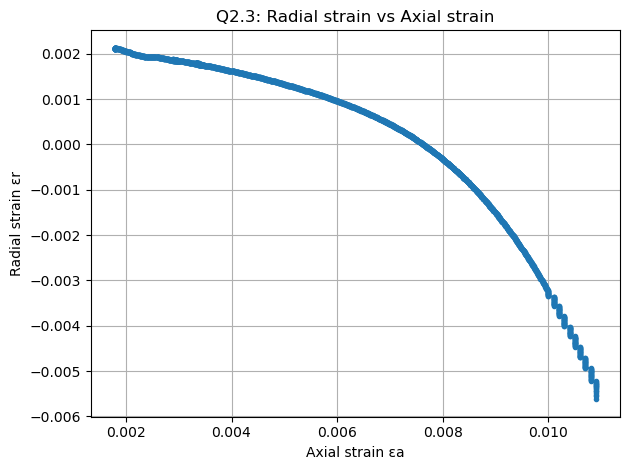

In [13]:
# ------------------------------------------
# Q2.3  —  Radial strain vs Axial strain plot
# ------------------------------------------

plt.figure()
plt.plot(Ex, Ey, 'o-', markersize=3)
plt.xlabel("Axial strain εa")
plt.ylabel("Radial strain εr")
plt.title("Q2.3: Radial strain vs Axial strain")
plt.grid(True)
plt.tight_layout()
plt.show()
